In [ ]:
%matplotlib widget
# %matplotlib inline

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

plt.close('all')



BASE_DATA_DIR = Path("/mnt/analysis/data/juicer_calib")
DATASETS = [
    # {"filename": "water_600_a4_a5.csv", "starting_mls": 600, "label": "Dataset 1 (charging)"}, 
    # {"filename": "water_600_a4_a5_again.csv", "starting_mls": 580, "label": "Dataset 2 (charging)"}, 
    # {"filename": "water_600_a4_a5_again_again.csv", "starting_mls": 584, "label": "Dataset 3 (charging)"},
    # {"filename": "water_600_a4_a5_power_off.csv", "starting_mls": 588, "label": "Dataset 4 (not charging)"}, 
    # {"filename": "water_600_a4_a5_power_off_again.csv", "starting_mls": 598, "label": "Dataset 5 (not charging)"},
    # {"filename": "test_new_electrode.csv", "starting_mls": 0, "label": "Dataset 6 (not charging)"},
    # {"filename": "test_new_electrode_stop_charger.csv", "starting_mls": 0, "label": "Dataset 7 (charging and not)"},
    # {"filename": "water_600_a4.csv", "starting_mls": 600, "label": "Dataset 8 (charging)"},
    {"filename": "water_600_a4_charger_off.csv", "starting_mls": 602, "label": "Dataset 9 (not charging)"},
    {"filename": "water_600_a4_charger_off_againn.csv", "starting_mls": 611, "label": "Dataset 10 (not charging)"}
]
REFERENCE_DATASET_IDX = 0
SENSOR_COLUMNS = ["juice_level_a4", "juice_level_a5"]
COLOR_PALETTE = ['blue', 'red', 'green', 'purple', 'brown', 'orange', 'cyan', 'magenta']


def load_calibration_runs(dataset_configs, base_dir):
    loaded_dfs = {}
    summary_rows = []
    for ds in dataset_configs:
        csv_path = base_dir / ds["filename"]
        df_temp = pd.read_csv(csv_path)
        df_temp["mls_remaining"] = ds["starting_mls"] - df_temp["reward_mls"]
        df_temp["dataset_label"] = ds["label"]
        loaded_dfs[ds["label"]] = df_temp
        summary_rows.append(
            {
                "dataset_label": ds["label"],
                "filename": ds["filename"],
                "starting_mls": ds["starting_mls"],
                "rows": len(df_temp),
                "mls_min": round(df_temp["mls_remaining"].min(), 1),
                "mls_max": round(df_temp["mls_remaining"].max(), 1),
            }
        )
    summary_df = pd.DataFrame(summary_rows)
    return loaded_dfs, summary_df


dfs, dataset_summary = load_calibration_runs(DATASETS, BASE_DATA_DIR)
reference_label = dataset_summary.iloc[REFERENCE_DATASET_IDX]["dataset_label"]
df_reference = dfs[reference_label]

print("=" * 80)
print(f"Reference dataset for fitting: {reference_label}")
print("Other datasets will be used for validation.")
print("=" * 80)

display(dataset_summary)


Reference dataset for fitting: Dataset 9 (charging)
Other datasets will be used for validation.


,dataset_label,filename,starting_mls,rows,mls_min,mls_max
0,Dataset 9 (charging),water_600_a4_charger_off.csv,602,420,-28.0,600.5
1,Dataset 10 (charging),water_600_a4_charger_off_againn.csv,611,420,-19.0,609.5


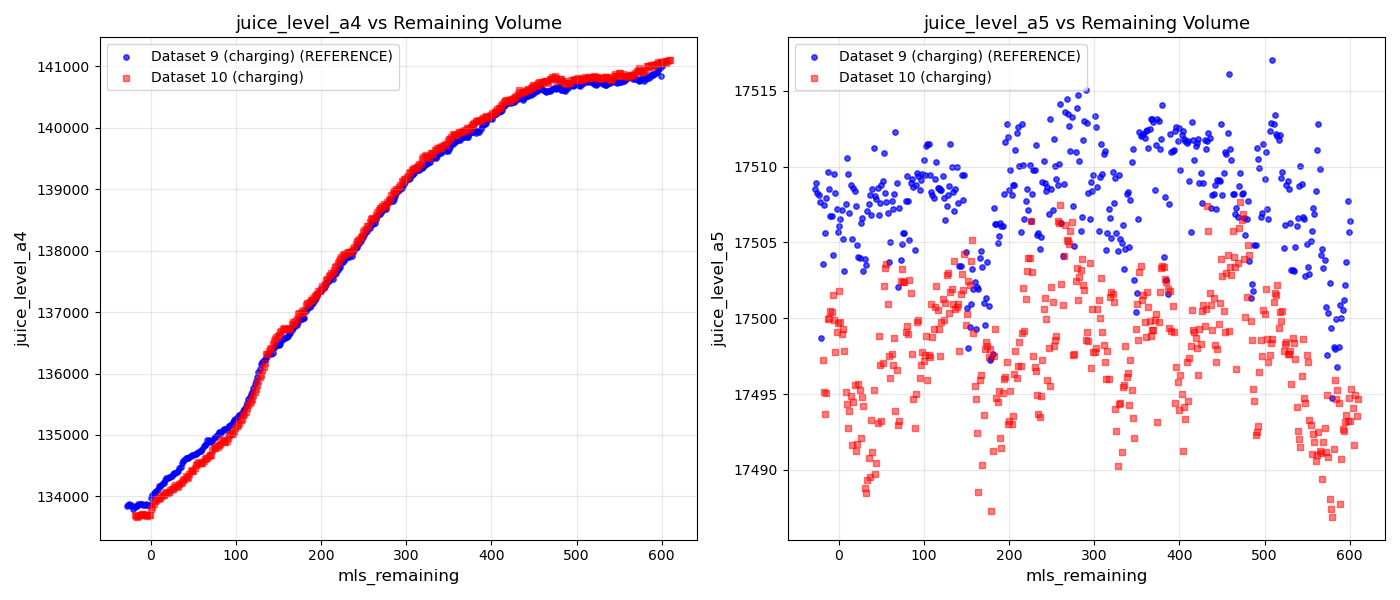

In [58]:
# Create figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
colors = COLOR_PALETTE[:len(dfs)]

# Plot 1: juice_level_a4 vs mls_remaining
for i, (label, df_plot) in enumerate(dfs.items()):
    marker_style = 'o' if label == reference_label else 's'
    alpha = 0.7 if label == reference_label else 0.5
    label_text = f"{label} (REFERENCE)" if label == reference_label else label
    ax1.scatter(
        df_plot['mls_remaining'],
        df_plot['juice_level_a4'],
        alpha=alpha,
        s=15,
        label=label_text,
        color=colors[i],
        marker=marker_style,
    )
ax1.set_xlabel('mls_remaining', fontsize=12)
ax1.set_ylabel('juice_level_a4', fontsize=12)
ax1.set_title('juice_level_a4 vs Remaining Volume', fontsize=13)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: juice_level_a5 vs mls_remaining
for i, (label, df_plot) in enumerate(dfs.items()):
    marker_style = 'o' if label == reference_label else 's'
    alpha = 0.7 if label == reference_label else 0.5
    label_text = f"{label} (REFERENCE)" if label == reference_label else label
    ax2.scatter(
        df_plot['mls_remaining'],
        df_plot['juice_level_a5'],
        alpha=alpha,
        s=15,
        label=label_text,
        color=colors[i],
        marker=marker_style,
    )
ax2.set_xlabel('mls_remaining', fontsize=12)
ax2.set_ylabel('juice_level_a5', fontsize=12)
ax2.set_title('juice_level_a5 vs Remaining Volume', fontsize=13)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Fitting on reference dataset: Dataset 9 (charging)

Model fit quality (R²):


/tmp/ipykernel_29932/1418225325.py:8: RuntimeWarning: invalid value encountered in log
  return a + b * np.log(x + c)


,sensor,Logarithmic R²,Sat. Exp R²,Double Sat. Exp R²
0,Sensor A4,0.981075,0.987136,NaN
1,Sensor A5,0.004044,0.009324,0.226003


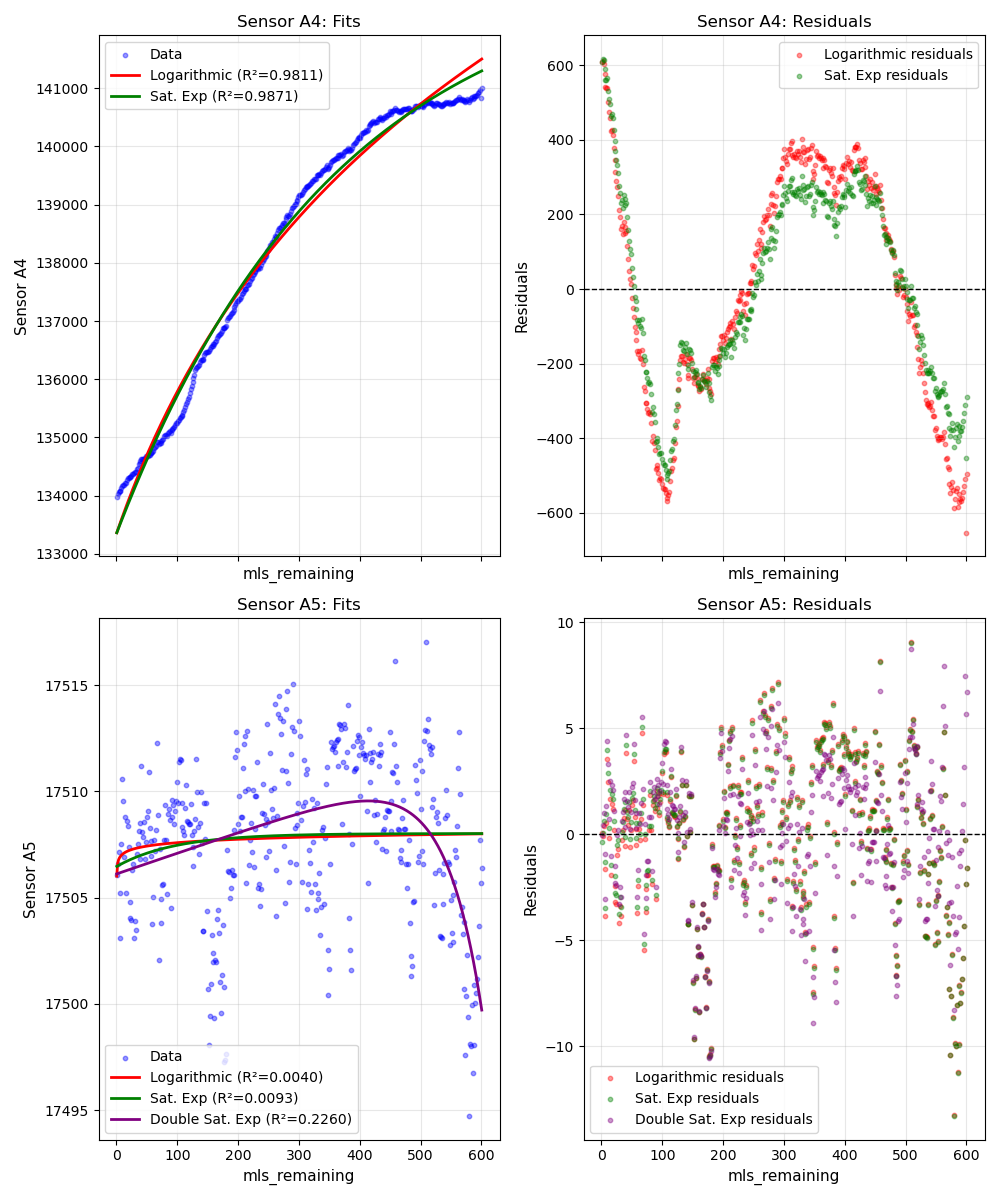

In [59]:
from scipy.optimize import curve_fit, brentq

DEFAULT_INVERSION_BOUNDS = (0, 650)


def log_func(x, a, b, c):
    """Logarithmic: y = a + b*ln(x + c)."""
    return a + b * np.log(x + c)


def sat_exp_func(x, A, B, k):
    """Saturating exponential: y = A - B*exp(-k*x)."""
    return A - B * np.exp(-k * x)


def double_sat_exp_func(x, A, B1, k1, B2, k2):
    """Sum of two saturating exponentials to capture multi-phase behavior."""
    return A - B1 * np.exp(-k1 * x) - B2 * np.exp(-k2 * x)


def inv_sat_exp_func(y, A, B, k):
    """Invert the saturating exponential to recover x (mls)."""
    ratio = (A - y) / B
    ratio = np.clip(ratio, 1e-9, None)
    return -np.log(ratio) / k


def inv_double_sat_exp_func(y_values, params, bounds=DEFAULT_INVERSION_BOUNDS):
    """Invert the double saturating exponential via root finding."""
    x_min, x_max = bounds

    def solve_single(y):
        f_min = double_sat_exp_func(x_min, *params) - y
        f_max = double_sat_exp_func(x_max, *params) - y
        if np.sign(f_min) == np.sign(f_max):
            return x_min if abs(f_min) < abs(f_max) else x_max
        try:
            return brentq(lambda x: double_sat_exp_func(x, *params) - y, x_min, x_max, maxiter=100)
        except ValueError:
            return x_min if abs(f_min) < abs(f_max) else x_max

    solver = np.vectorize(solve_single, otypes=[float])
    return solver(y_values)


def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot if ss_tot else np.nan


MODEL_SPECS = {
    "log": {"label": "Logarithmic", "init_key": "log_init", "func": log_func, "color": "red"},
    "exp": {"label": "Sat. Exp", "init_key": "exp_init", "func": sat_exp_func, "color": "green"},
    "double_exp": {
        "label": "Double Sat. Exp",
        "init_key": "double_exp_init",
        "func": double_sat_exp_func,
        "color": "purple",
    },
}

FIT_CONFIG = {
    "juice_level_a4": {
        "label": "Sensor A4",
        "models": ["log", "exp"],
        "log_init": [160000, 1000, 1],
        "exp_init": [160000, 10000, 0.01],
        "inversion_model": "exp",
        "inversion_bounds": DEFAULT_INVERSION_BOUNDS,
    },
    "juice_level_a5": {
        "label": "Sensor A5",
        "models": ["log", "exp", "double_exp"],
        "log_init": [43000, 1000, 1],
        "exp_init": [43000, 10000, 0.01],
        "double_exp_init": [45000, 15000, 0.002, 6000, 0.02],
        "inversion_model": "double_exp",
        "inversion_bounds": DEFAULT_INVERSION_BOUNDS,
    },
}

# Use reference dataset for fitting
df_fit = dfs[reference_label]
df_valid = df_fit[df_fit['mls_remaining'] >= 0].copy()
x_data = df_valid['mls_remaining'].values

sensor_fit_results = {}
summary_rows = []

print(f"Fitting on reference dataset: {reference_label}")
print("=" * 80)
for sensor in SENSOR_COLUMNS:
    cfg = FIT_CONFIG[sensor]
    y_data = df_valid[sensor].values
    result = {"label": cfg["label"], "data": y_data, "models": {}}

    for model_key in cfg.get("models", MODEL_SPECS.keys()):
        spec = MODEL_SPECS[model_key]
        init_key = spec["init_key"]
        init_guess = cfg.get(init_key)
        if init_guess is None:
            continue
        try:
            popt, _ = curve_fit(spec["func"], x_data, y_data, p0=init_guess, maxfev=20000)
            y_pred = spec["func"](x_data, *popt)
            result["models"][model_key] = {
                "params": popt,
                "pred": y_pred,
                "r2": r2_score(y_data, y_pred),
            }
        except Exception as exc:
            print(f"{spec['label']} fit failed for {cfg['label']}: {exc}")

    sensor_fit_results[sensor] = result
    row = {"sensor": cfg["label"]}
    for model_key, model_data in result["models"].items():
        row[f"{MODEL_SPECS[model_key]['label']} R²"] = model_data["r2"]
    summary_rows.append(row)

fit_summary = pd.DataFrame(summary_rows)
print("\nModel fit quality (R²):")
display(fit_summary)

# Plot the fits and residuals
fig, axes = plt.subplots(len(SENSOR_COLUMNS), 2, figsize=(10, 6 * len(SENSOR_COLUMNS)), sharex='col')
if len(SENSOR_COLUMNS) == 1:
    axes = np.array([axes])

for row_idx, sensor in enumerate(SENSOR_COLUMNS):
    result = sensor_fit_results[sensor]
    label = result["label"]
    axes[row_idx, 0].scatter(x_data, result["data"], alpha=0.4, s=10, label='Data', color='blue')
    for model_key, model_data in result["models"].items():
        spec = MODEL_SPECS[model_key]
        axes[row_idx, 0].plot(
            x_data,
            model_data["pred"],
            color=spec["color"],
            linewidth=2,
            label=f"{spec['label']} (R²={model_data['r2']:.4f})",
        )
    axes[row_idx, 0].set_xlabel('mls_remaining', fontsize=11)
    axes[row_idx, 0].set_ylabel(label, fontsize=11)
    axes[row_idx, 0].set_title(f'{label}: Fits', fontsize=12)
    axes[row_idx, 0].legend()
    axes[row_idx, 0].grid(True, alpha=0.3)

    for model_key, model_data in result["models"].items():
        spec = MODEL_SPECS[model_key]
        axes[row_idx, 1].scatter(
            x_data,
            result["data"] - model_data["pred"],
            alpha=0.4,
            s=10,
            label=f'{spec["label"]} residuals',
            color=spec["color"],
        )
    axes[row_idx, 1].axhline(y=0, color='black', linestyle='--', linewidth=1)
    axes[row_idx, 1].set_xlabel('mls_remaining', fontsize=11)
    axes[row_idx, 1].set_ylabel('Residuals', fontsize=11)
    axes[row_idx, 1].set_title(f'{label}: Residuals', fontsize=12)
    axes[row_idx, 1].legend()
    axes[row_idx, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [60]:
def compute_mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))


def invert_sensor(sensor_name, sensor_values):
    cfg = FIT_CONFIG[sensor_name]
    model_choice = cfg.get("inversion_model", "exp")
    model_data = sensor_fit_results[sensor_name]["models"].get(model_choice)
    if model_data is None or model_data["params"] is None:
        available = ", ".join(sensor_fit_results[sensor_name]["models"].keys())
        raise ValueError(
            f"Missing parameters for {sensor_name} inversion model '{model_choice}'."
            f" Available fits: {available}"
        )

    if model_choice == "exp":
        preds = inv_sat_exp_func(sensor_values, *model_data["params"])
    elif model_choice == "double_exp":
        bounds = cfg.get("inversion_bounds", DEFAULT_INVERSION_BOUNDS)
        preds = inv_double_sat_exp_func(sensor_values, model_data["params"], bounds)
    else:
        raise ValueError(f"Unsupported inversion model '{model_choice}' for {sensor_name}.")

    return np.maximum(preds, 0)


ref_valid = df_reference[df_reference['mls_remaining'] >= 0].copy()
y_actual = ref_valid['mls_remaining'].values
sensor_predictions = {}
metrics_rows = []

for sensor in SENSOR_COLUMNS:
    preds = invert_sensor(sensor, ref_valid[sensor].values)
    sensor_predictions[sensor] = preds
    metrics_rows.append(
        {
            "model": f"{FIT_CONFIG[sensor]['label']} ({FIT_CONFIG[sensor]['inversion_model']})",
            "MAE": compute_mae(y_actual, preds),
            "R2": r2_score(y_actual, preds),
        }
    )

prediction_matrix = np.column_stack([sensor_predictions[s] for s in SENSOR_COLUMNS])
mean_preds = prediction_matrix.mean(axis=1)
metrics_rows.append(
    {
        "model": "Simple average",
        "MAE": compute_mae(y_actual, mean_preds),
        "R2": r2_score(y_actual, mean_preds),
    }
)

weights, _, _, _ = np.linalg.lstsq(prediction_matrix, y_actual, rcond=None)
weights = np.clip(weights, 0, None)
if weights.sum():
    weights = weights / weights.sum()
combined_preds = prediction_matrix @ weights
metrics_rows.append(
    {
        "model": "Optimally weighted",
        "MAE": compute_mae(y_actual, combined_preds),
        "R2": r2_score(y_actual, combined_preds),
    }
)

WEIGHT_MAP = dict(zip(SENSOR_COLUMNS, weights))
WEIGHT_A4 = WEIGHT_MAP.get("juice_level_a4", 0.0)
WEIGHT_A5 = WEIGHT_MAP.get("juice_level_a5", 0.0)

metrics_df = pd.DataFrame(metrics_rows)
print("=" * 80)
print("COMPARISON: Individual vs Combined Predictions")
print("=" * 80)
display(metrics_df)
print("Selected weights (sum to 1):")
for sensor, w in WEIGHT_MAP.items():
    print(f"  {FIT_CONFIG[sensor]['label']}: {w:.3f}")


COMPARISON: Individual vs Combined Predictions


,model,MAE,R2
0,Sensor A4 (exp),20.606350,0.978469
1,Sensor A5 (double_exp),283.434446,-2.648685
2,Simple average,140.853621,0.111857
3,Optimally weighted,18.771888,0.979615


Selected weights (sum to 1):
  Sensor A4: 0.967
  Sensor A5: 0.033


VALIDATION: Testing fitted parameters on all datasets

Dataset 9 (charging) [REFERENCE (used for fitting)]:
  Samples: 401
  MAE: 18.77 mls
  R²: 0.9796
  By volume range:
      0-100 mls: MAE=14.89 mls, n= 67
    100-200 mls: MAE=11.44 mls, n= 66
    200-300 mls: MAE= 9.13 mls, n= 67
    300-400 mls: MAE=16.76 mls, n= 67
    400-600 mls: MAE=29.84 mls, n=133

Dataset 10 (charging) [VALIDATION]:
  Samples: 407
  MAE: 24.67 mls
  R²: 0.9719
  By volume range:
      0-100 mls: MAE=15.17 mls, n= 67
    100-200 mls: MAE= 7.59 mls, n= 66
    200-300 mls: MAE=16.22 mls, n= 67
    300-400 mls: MAE=42.52 mls, n= 67
    400-600 mls: MAE=32.24 mls, n=133

Summary:


,dataset,type,samples,MAE,R2
0,Dataset 9 (charging),REFERENCE,401,18.771888,0.979615
1,Dataset 10 (charging),VALIDATION,407,24.669257,0.971881


INTERPRETATION:
- REFERENCE: Expected to perform well (model was trained on this data)
- VALIDATION: Tests if calibration generalizes to new data
- Divergent MAE/R² suggests recalibration or additional data collection


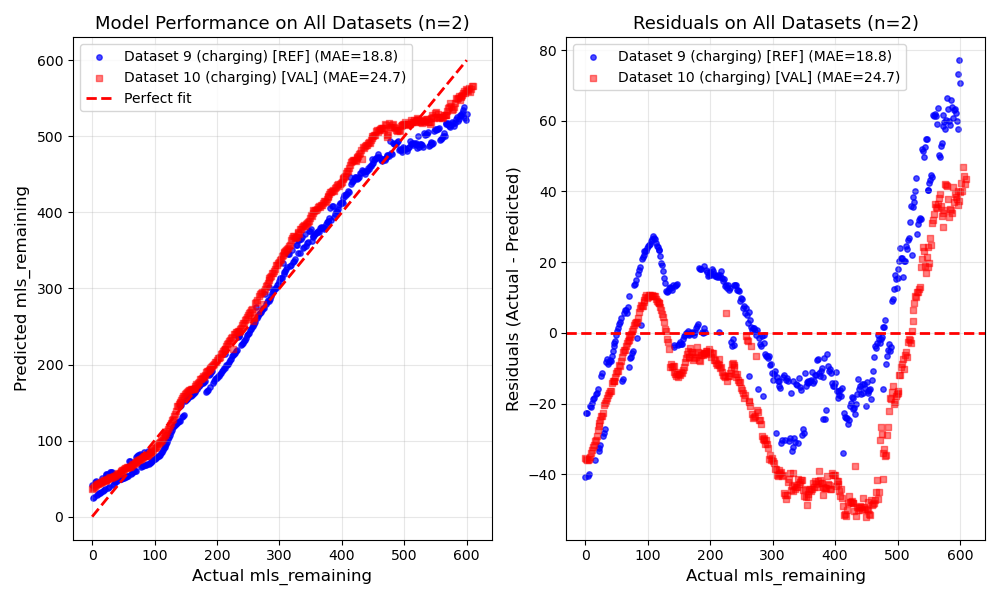

In [61]:
# ============================================================================
# CROSS-DATASET VALIDATION
# Test if the fitted parameters generalize beyond the reference run
# ============================================================================

print("=" * 80)
print("VALIDATION: Testing fitted parameters on all datasets")
print("=" * 80)

validation_rows = []
volume_bins = [(0, 100), (100, 200), (200, 300), (300, 400), (400, 600)]

for ds_label, df_test in dfs.items():
    df_test_valid = df_test[df_test['mls_remaining'] >= 0].copy()
    if df_test_valid.empty:
        continue

    actual = df_test_valid['mls_remaining'].values
    combined_pred = sum(
        WEIGHT_MAP[sensor] * invert_sensor(sensor, df_test_valid[sensor].values)
        for sensor in SENSOR_COLUMNS
    )
    combined_pred = np.maximum(combined_pred, 0)

    mae_combined = compute_mae(actual, combined_pred)
    r2_combined = r2_score(actual, combined_pred)
    dataset_type = "REFERENCE (used for fitting)" if ds_label == reference_label else "VALIDATION"

    print(f"\n{ds_label} [{dataset_type}]:")
    print(f"  Samples: {len(df_test_valid)}")
    print(f"  MAE: {mae_combined:.2f} mls")
    print(f"  R²: {r2_combined:.4f}")
    print("  By volume range:")
    for low, high in volume_bins:
        mask = (actual >= low) & (actual < high)
        if mask.sum():
            bin_mae = compute_mae(actual[mask], combined_pred[mask])
            print(f"    {low:3d}-{high:3d} mls: MAE={bin_mae:5.2f} mls, n={mask.sum():3d}")

    validation_rows.append(
        {
            "dataset": ds_label,
            "type": "REFERENCE" if ds_label == reference_label else "VALIDATION",
            "samples": len(df_test_valid),
            "MAE": mae_combined,
            "R2": r2_combined,
        }
    )

validation_df = pd.DataFrame(validation_rows)
print("\nSummary:")
display(validation_df)

print("=" * 80)
print("INTERPRETATION:")
print("=" * 80)
print("- REFERENCE: Expected to perform well (model was trained on this data)")
print("- VALIDATION: Tests if calibration generalizes to new data")
print("- Divergent MAE/R² suggests recalibration or additional data collection")
print("=" * 80)

colors = COLOR_PALETTE[:len(dfs)]
fig, axes = plt.subplots(1, 2, figsize=(10, 6))

for idx, (ds_label, df_test) in enumerate(dfs.items()):
    df_test_valid = df_test[df_test['mls_remaining'] >= 0].copy()
    if df_test_valid.empty:
        continue

    actual = df_test_valid['mls_remaining'].values
    combined_pred = sum(
        WEIGHT_MAP[sensor] * invert_sensor(sensor, df_test_valid[sensor].values)
        for sensor in SENSOR_COLUMNS
    )
    combined_pred = np.maximum(combined_pred, 0)

    mae = compute_mae(actual, combined_pred)
    marker_style = 'o' if ds_label == reference_label else 's'
    alpha_val = 0.7 if ds_label == reference_label else 0.5
    dataset_type = "REF" if ds_label == reference_label else "VAL"

    axes[0].scatter(
        actual,
        combined_pred,
        alpha=alpha_val,
        s=15,
        label=f'{ds_label} [{dataset_type}] (MAE={mae:.1f})',
        color=colors[idx],
        marker=marker_style,
    )

    residuals = actual - combined_pred
    axes[1].scatter(
        actual,
        residuals,
        alpha=alpha_val,
        s=15,
        label=f'{ds_label} [{dataset_type}] (MAE={mae:.1f})',
        color=colors[idx],
        marker=marker_style,
    )

axes[0].plot([0, 600], [0, 600], 'r--', lw=2, label='Perfect fit')
axes[0].set_xlabel('Actual mls_remaining', fontsize=12)
axes[0].set_ylabel('Predicted mls_remaining', fontsize=12)
axes[0].set_title(f'Model Performance on All Datasets (n={len(dfs)})', fontsize=13)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Actual mls_remaining', fontsize=12)
axes[1].set_ylabel('Residuals (Actual - Predicted)', fontsize=12)
axes[1].set_title(f'Residuals on All Datasets (n={len(dfs)})', fontsize=13)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


GLOBAL SENSOR A5 FIT (SATURATING EXP) ACROSS ALL DATASETS


,Model,R²,MAE (sensor units)
0,Sat. Exp,0.007659,5.406998



Best combined-data model: Sat. Exp (R²=0.0077)
Parameters: [1.7503e+04, 2.8988e+00, 1.8655e-02]


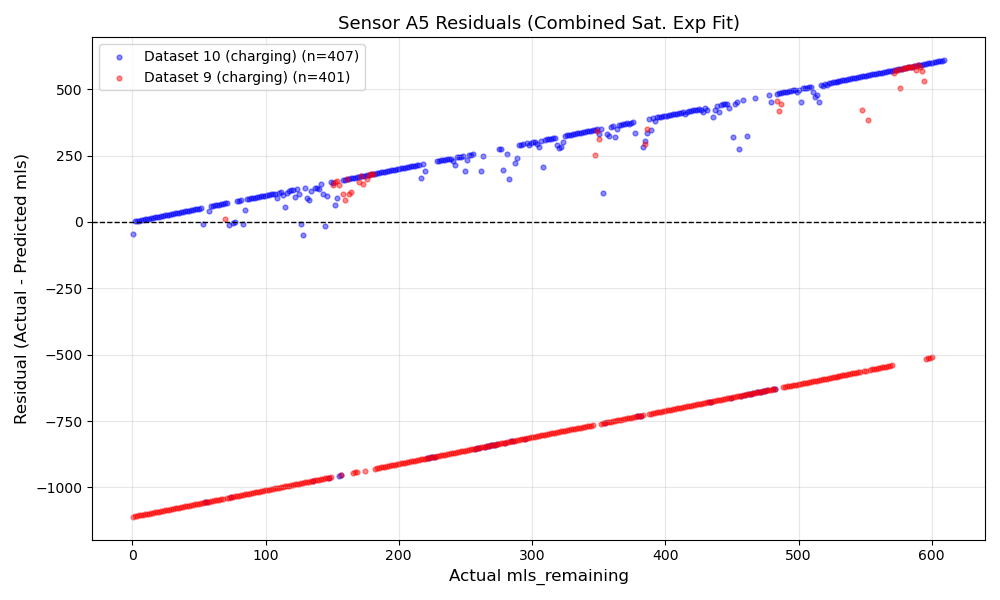

In [62]:
print("=" * 80)
print("GLOBAL SENSOR A5 FIT (SATURATING EXP) ACROSS ALL DATASETS")
print("=" * 80)

combined_a5_df = pd.concat(
    [
        df[df['mls_remaining'] >= 0][['mls_remaining', 'juice_level_a5', 'dataset_label']]
        for df in dfs.values()
    ],
    ignore_index=True,
)

x_all = combined_a5_df['mls_remaining'].values
y_all = combined_a5_df['juice_level_a5'].values
cfg_a5 = FIT_CONFIG['juice_level_a5']
spec_exp = MODEL_SPECS['exp']
init_guess = cfg_a5.get(spec_exp['init_key'])

popt, _ = curve_fit(spec_exp['func'], x_all, y_all, p0=init_guess, maxfev=40000)
preds = spec_exp['func'](x_all, *popt)
r2_val = r2_score(y_all, preds)
mae_val = compute_mae(y_all, preds)
summary_df = pd.DataFrame(
    [{"Model": spec_exp["label"], "R²": r2_val, "MAE (sensor units)": mae_val}]
)
display(summary_df)

print(f"\nBest combined-data model: {spec_exp['label']} (R²={r2_val:.4f})")
print("Parameters:", np.array2string(popt, precision=4, separator=', '))

fig, ax = plt.subplots(figsize=(10, 6))
for idx, (ds_label, df_group) in enumerate(combined_a5_df.groupby('dataset_label')):
    actual_mls = df_group['mls_remaining'].values
    predicted_mls = inv_sat_exp_func(df_group['juice_level_a5'].values, *popt)
    predicted_mls = np.clip(predicted_mls, 0, None)
    residuals = actual_mls - predicted_mls
    ax.scatter(
        actual_mls,
        residuals,
        s=12,
        alpha=0.45,
        color=COLOR_PALETTE[idx % len(COLOR_PALETTE)],
        label=f"{ds_label} (n={len(df_group)})",
    )

ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Actual mls_remaining', fontsize=12)
ax.set_ylabel('Residual (Actual - Predicted mls)', fontsize=12)
ax.set_title('Sensor A5 Residuals (Combined Sat. Exp Fit)', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


SENSOR A5 DOUBLE-LOGISTIC FIT EXPERIMENT


,Model,R²,MAE (sensor units)
0,Sat. Exp,0.007659,5.406998
1,Double logistic,0.005116,5.404397


Double logistic parameters:
[ 1.6079e+01,  4.9861e-01, -4.9097e+01,  1.3765e+00,  2.2695e-02,
  1.3910e+02,  1.7486e+04]


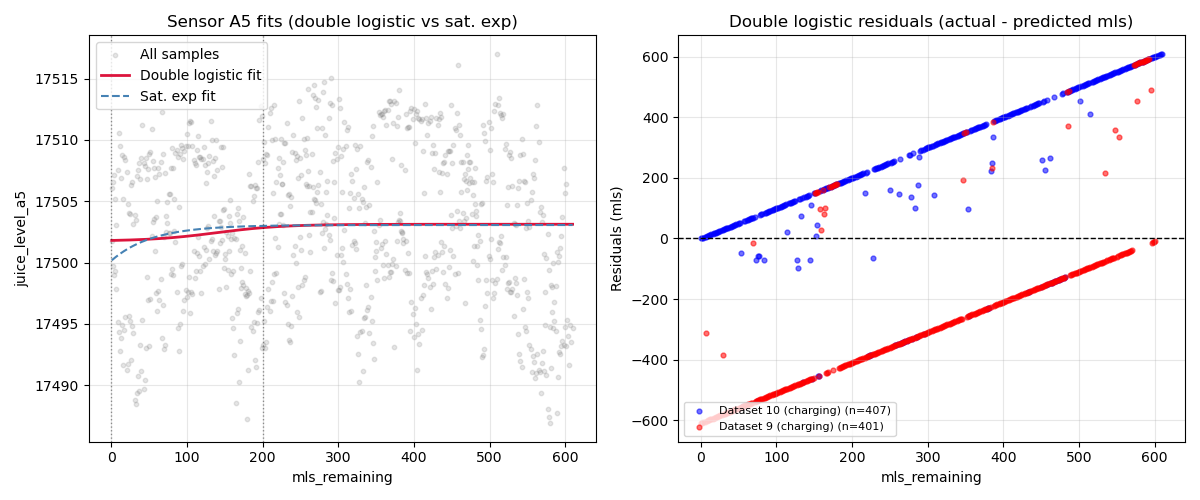

In [63]:
print("=" * 80)
print("SENSOR A5 DOUBLE-LOGISTIC FIT EXPERIMENT")
print("=" * 80)

from scipy.interpolate import interp1d
from scipy.special import expit

def double_logistic_func(x, L1, k1, x01, L2, k2, x02, baseline):
    x = np.asarray(x, dtype=float)
    return baseline + L1 * expit(k1 * (x - x01)) + L2 * expit(k2 * (x - x02))

y_min, y_max = y_all.min(), y_all.max()
span = y_max - y_min
init_guess = [
    span * 0.55,
    0.04,
    20.0,
    span * 0.45,
    0.02,
    220.0,
    y_min,
]
bounds = (
    [0, 1e-4, -50, 0, 1e-4, 120, y_min - span],
    [span * 2, 0.5, 80, span * 2, 0.5, 320, y_max + span],
)

popt_double, _ = curve_fit(
    double_logistic_func,
    x_all,
    y_all,
    p0=init_guess,
    bounds=bounds,
    maxfev=60000,
)

preds_double = double_logistic_func(x_all, *popt_double)
r2_double = r2_score(y_all, preds_double)
mae_double = compute_mae(y_all, preds_double)

comparison_df = pd.DataFrame(
    [
        {"Model": "Sat. Exp", "R²": r2_val, "MAE (sensor units)": mae_val},
        {"Model": "Double logistic", "R²": r2_double, "MAE (sensor units)": mae_double},
    ]
)
display(comparison_df)

print("Double logistic parameters:")
print(np.array2string(popt_double, precision=4, separator=', '))

x_grid_dense = np.linspace(x_all.min(), x_all.max(), 5000)
y_grid_dense = double_logistic_func(x_grid_dense, *popt_double)
if np.any(np.diff(y_grid_dense) <= 0):
    print(
        "Warning: double logistic fit is not strictly monotonic; mls residuals may be unreliable."
    )
inv_double_logistic = interp1d(
    y_grid_dense,
    x_grid_dense,
    bounds_error=False,
    fill_value=(x_grid_dense[0], x_grid_dense[-1]),
    assume_sorted=True,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(x_all, y_all, s=10, alpha=0.2, label='All samples', color='gray')
x_grid = np.linspace(x_all.min(), x_all.max(), 800)
axes[0].plot(
    x_grid,
    double_logistic_func(x_grid, *popt_double),
    color='crimson',
    linewidth=2,
    label='Double logistic fit',
)
axes[0].plot(
    x_grid,
    spec_exp['func'](x_grid, *popt),
    color='steelblue',
    linestyle='--',
    linewidth=1.5,
    label='Sat. exp fit',
)
for xpos in (0, 200):
    axes[0].axvline(xpos, color='black', linestyle=':', linewidth=1, alpha=0.4)
axes[0].set_xlabel('mls_remaining')
axes[0].set_ylabel('juice_level_a5')
axes[0].set_title('Sensor A5 fits (double logistic vs sat. exp)')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
for idx, (ds_label, df_group) in enumerate(combined_a5_df.groupby('dataset_label')):
    actual_mls = df_group['mls_remaining'].values
    sensor_vals = df_group['juice_level_a5'].values
    predicted_mls = inv_double_logistic(sensor_vals)
    residuals_mls = actual_mls - predicted_mls
    axes[1].scatter(
        actual_mls,
        residuals_mls,
        alpha=0.55,
        s=12,
        label=f"{ds_label} (n={len(df_group)})",
        color=COLOR_PALETTE[idx % len(COLOR_PALETTE)],
    )
axes[1].set_xlabel('mls_remaining')
axes[1].set_ylabel('Residuals (mls)')
axes[1].set_title('Double logistic residuals (actual - predicted mls)')
axes[1].legend(loc='lower left', fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

